In [32]:
%load_ext autoreload
%autoreload 2

import sys
import os

dir_name = '/home/guerrini/sp_validation/notebooks/cosmo_val'
if dir_name not in sys.path:
    sys.path.append(dir_name)

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.cosmology import Planck18
import healpy as hp
import camb
from cosmology import Cosmology
from cosmo_val import CosmologyValidation
import pyccl as ccl
import fitsio

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
cl = np.load("/n09data/guerrini/glass_mock_v1.4.6/results/cl_glass_mock_00001_4096.npy")

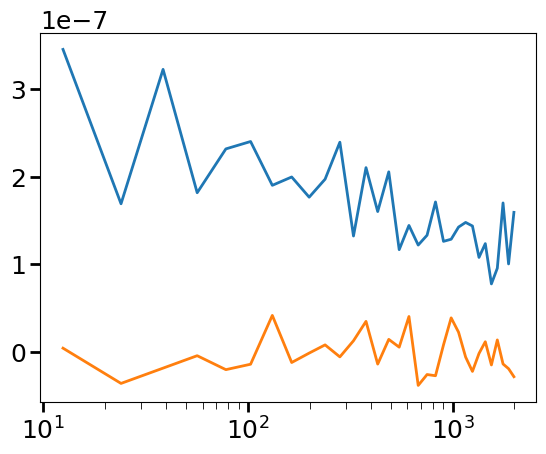

In [34]:
plt.figure()

plt.plot(cl[0], cl[0]*cl[1])
plt.plot(cl[0], cl[0]*cl[4])
plt.xscale('log')

plt.show()

In [35]:
root_dir_glass_mock = '/n09data/guerrini/glass_mock_v1.4.6/results/'
root_dir_target_cat = '/n17data/UNIONS/WL/v1.4.x/v1.4.6/'
n_sim = 1
index_sim = str(n_sim).zfill(5)
glass_mock = f'unions_glass_sim_{index_sim}_4096.fits'
target_mock = 'unions_shapepipe_cut_struc_2024_v1.4.6.fits'

root_dirs = [root_dir_glass_mock, root_dir_target_cat]
cats = [glass_mock, target_mock]
labels = ['glass_mock', 'target_mock']
w_cols = ['w', 'w_des'] 

In [36]:
#Create n_gal maps
for root_dir, cat, label, w_col in zip(root_dirs, cats, labels, w_cols):
    data = fits.getdata(root_dir + cat)

    if label == 'glass_mock':
        n_gal = np.zeros(hp.nside2npix(4096))
        
        ra = data['ra']
        dec = data['dec']
        pix = hp.ang2pix(4096, np.radians(90 - dec), np.radians(ra))

        unique_pix, idx, idx_rep = np.unique(pix, return_index=True, return_inverse=True)
        n_gal[unique_pix] = np.bincount(idx_rep)
        mask = n_gal != 0

        area = np.sum(mask) * hp.nside2pixarea(4096, degrees=True)
        del n_gal, mask

    if label == 'target_mock':
        area = 2400
    print(f"Area of {label} = {area} deg^2")
        

    #Compute effective number of galaxies
    e1 = data['e1']
    e2 = data['e2']
    
    
    n_eff_gal = 1/(area*60*60)*(np.sum(data[w_col]))**2/np.sum(data[w_col]**2)
    print(f"n_eff_gal of {label} = {n_eff_gal} arcmin^-2")

    #Compute shape noise
    sigma_e = np.sqrt(
    0.5*(np.sum((data['e1']*data[w_col])**2) + np.sum((data['e2']*data[w_col])**2)) / np.sum(data[w_col]**2)
    )
    print(f"sigma_e of {label} = {sigma_e}")

Area of glass_mock = 1572.357426563017 deg^2
n_eff_gal of glass_mock = 6.1971223745152475 arcmin^-2
sigma_e of glass_mock = 0.26818686112319395
Area of target_mock = 2400 deg^2
n_eff_gal of target_mock = 6.141962124965772 arcmin^-2
sigma_e of target_mock = 0.26840896706663514


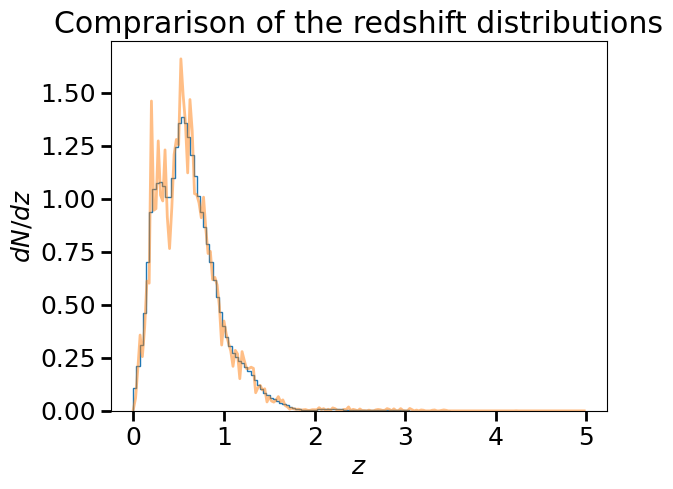

In [37]:
#Check the redshift distribution
glass_cat = fits.getdata(root_dir_glass_mock + glass_mock)

plt.figure()

plt.hist(glass_cat['PHOTO_Z'], bins=100, histtype='step', label='glass_mock', density=True)

redshift_distr = np.loadtxt('/n17data/sguerrini/UNIONS/WL/nz/v1.4.6/nz_SP_v1.4.6_A.txt')
z, dndz = redshift_distr[:, 0], redshift_distr[:, 1]

plt.plot(z, dndz, label='SP_A', alpha=0.5)

plt.xlabel(r'$z$')
plt.ylabel(r'$dN/dz$')
plt.title('Comprarison of the redshift distributions')

plt.show()


In [38]:
#Compute theory Cl'set
planck18 = Planck18
h = planck18.H0.value/100
Om = planck18.Om0
Ob = planck18.Ob0
Oc = Om - Ob
ns = 0.965
As = 2.1e-9

pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, As=As,
                                    NonLinear=camb.model.NonLinear_both, WantTransfer=True)

nside = 1024
lmax = 2*nside

#getthe expected cl's from CAMB
pars.min_l = 1
pars.set_for_lmax(lmax)
pars.SourceWindows = [
    camb.sources.SplinedSourceWindow(z=z, W=dndz, source_type='lensing')
]
theory_cls = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)


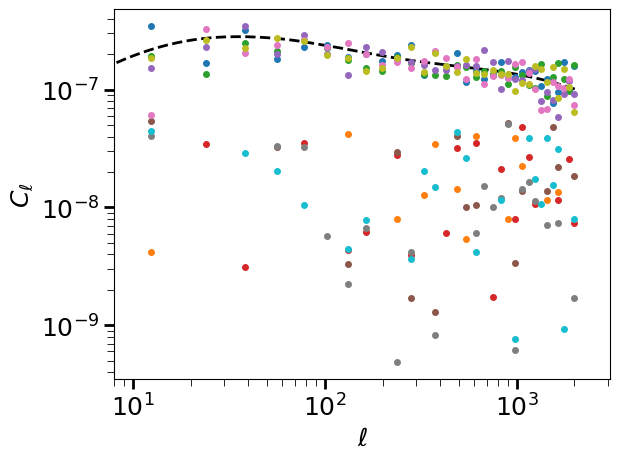

In [39]:
l = np.arange(lmax+1)
pw = hp.pixwin(nside, lmax=lmax)

plt.figure()

for n_sim in range(1, 6):
    index_sim = str(n_sim).zfill(5)
    pseudo_cl_glass = np.load(f"{root_dir_glass_mock}/cl_glass_mock_{index_sim}_4096.npy")

    ell_eff = pseudo_cl_glass[0]



    plt.errorbar(ell_eff, ell_eff*pseudo_cl_glass[1], fmt='o', capsize=2, markersize=4, label='EE')
    plt.errorbar(ell_eff, ell_eff*pseudo_cl_glass[4], fmt='o', capsize=2, markersize=4, label='BB')
plt.plot(l, l*theory_cls['W1xW1'], label=r'$C_\ell$ theory', c='k', ls='--')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')


plt.xscale('log')
plt.yscale('log')

plt.xlim(8, 3*nside-1)

plt.show()

In [40]:
#Get theory correlation function from CCL
#Define the cosmology
theta_arcmin = np.logspace(np.log10(0.1), np.log10(250), 1000)
h = planck18.H0.value/100
Oc = planck18.Om0 - planck18.Ob0
Ob = planck18.Ob0
sigma8 = float(camb.get_results(pars).get_sigma8())
n_s = 0.965
cosmo = ccl.Cosmology(
    h=h,
    Omega_c = Oc,
    Omega_b = Ob,
    sigma8 = sigma8,
    n_s = n_s,
    transfer_function='boltzmann_camb',
)

#Define the redshift distribution
z, dndz = np.loadtxt('/n17data/sguerrini/UNIONS/WL/nz/v1.4.6/nz_SP_v1.4.6_A.txt', unpack=True)

tracer = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz), ia_bias=None)

#COmpute the angular power spectrum C_ell
ell = np.logspace(0, np.log10(10000), 2000)
cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell)

#Compute the 2PCF
theta_deg = theta_arcmin / 60
#xi+ fit
xi_p_theta = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG+')
#xi- fit
xi_m_theta = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG-')

/tmp/ipykernel_181795/1579801276.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma8 = float(camb.get_results(pars).get_sigma8())


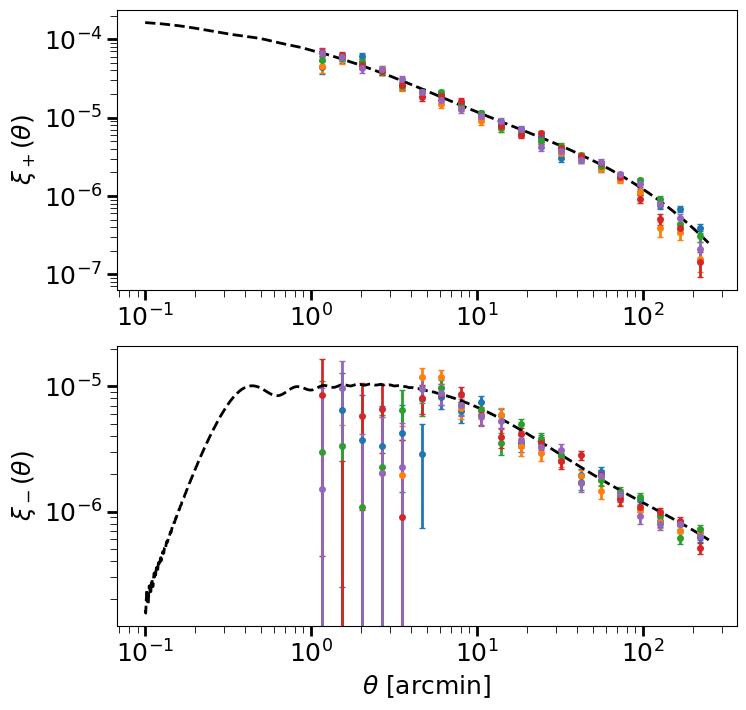

In [41]:
import treecorr 

n_sim = 1
index_sim = str(n_sim).zfill(5)

theta_min = 1.0
theta_max = 250.0
nbins = 20
var_method = 'jackknife'

treecorr_config = {
            "ra_units": "degrees",
            "dec_units": "degrees",
            "min_sep": theta_min,
            "max_sep": theta_max,
            "sep_units": "arcmin",
            "nbins": nbins,
            "var_method": var_method,
        }

gg = treecorr.GGCorrelation(treecorr_config)

#Load the measurement
gg.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')


plt.figure(figsize=(8, 8))

plt.subplot(211)

for i in range(1, 6):
    index_sim = str(i).zfill(5)
    gg.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')

    plt.errorbar(gg.meanr, gg.xip, yerr=np.sqrt(gg.varxip), fmt='o', label=r'$\xi_+$ data', capsize=2, markersize=4)
plt.plot(theta_arcmin, xi_p_theta, label=r'$\xi_+$ theory', linestyle='--', color='black')

plt.yscale('log')
plt.xscale('log')

plt.ylabel(r'$\xi_+(\theta)$')

plt.subplot(212)

for i in range(1, 6):
    index_sim = str(i).zfill(5)
    gg.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')

    plt.errorbar(gg.meanr, gg.xim, yerr=np.sqrt(gg.varxim), fmt='o', label=r'$\xi_-$ data', capsize=2, markersize=4)
plt.plot(theta_arcmin, xi_m_theta, label=r'$\xi_-$ theory', linestyle='--', color='black')

plt.yscale('log')
plt.xscale('log')

plt.ylabel(r'$\xi_-(\theta)$')
plt.xlabel(r'$\theta$ [arcmin]')

plt.savefig('validate_mock.png')
plt.show()

In [20]:
sigma8

0.7875554426097456

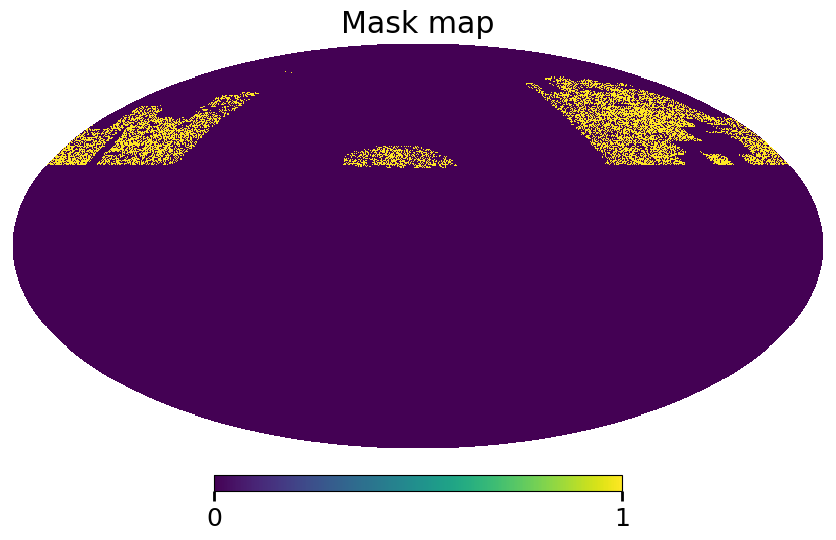

In [21]:
import healpy as hp

mask_path = f"{root_dir_glass_mock}/../mask_nside4096.fits"

mask_map = hp.read_map(mask_path)

hp.mollview(mask_map, title='Mask map')

plt.show()

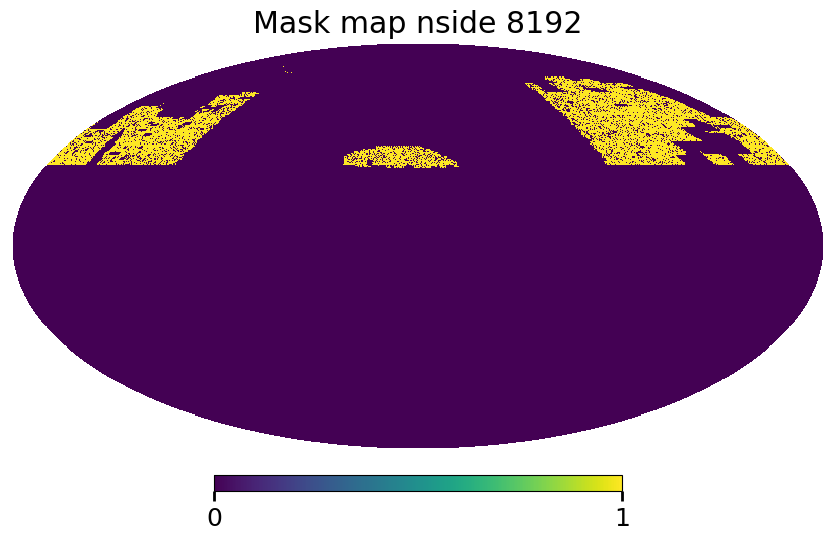

In [22]:
mask_path = "/home/guerrini/sp_validation/cosmo_inference/data/mask/mask_map_v1.4.6_nside_8192.fits"

mask_map = hp.read_map(mask_path)

hp.mollview(mask_map, title='Mask map nside 8192')
plt.show()

In [31]:
area = np.sum(mask_map) * hp.nside2pixarea(8192, degrees=True)
print(f"Area of the mask = {area} deg^2")

Area of the mask = 2405.3892055695346 deg^2


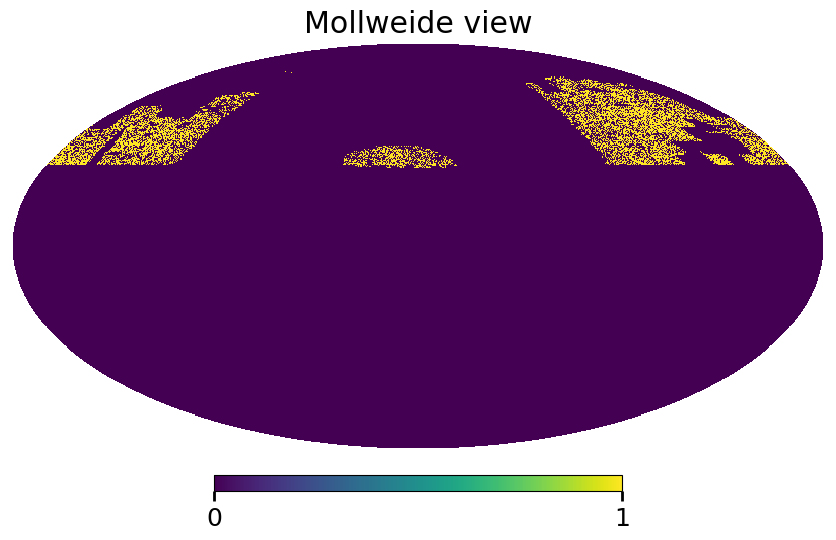

In [23]:
hp.mollview(hp.ud_grade(mask_map, 4096))
plt.show()

In [33]:
down_mask = hp.ud_grade(mask_map, 4096)
down_mask[down_mask < 0.75] = 0
down_mask[down_mask >= 0.75] = 1
area = np.sum(down_mask) * hp.nside2pixarea(4096, degrees=True)
print(f"Area of the mask = {area} deg^2")

Area of the mask = 1600.3319689504215 deg^2
